In [ ]:

!apt-get -qq update
!apt-get -qq install -y default-jdk
!pip -q install -U konlpy JPype1 gensim pandas matplotlib nltk tqdm


W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package libatspi2.0-0:amd64.
(Reading database ... 118243 files and directories currently installed.)
Preparing to unpack .../00-libatspi2.0-0_2.44.0-3_amd64.deb ...
Unpacking libatspi2.0-0:amd64 (2.44.0-3) ...
Selecting previously unselected package libxtst6:amd64.
Preparing to unpack .../01-libxtst6_2%3a1.2.3-1build4_amd64.deb ...
Unpacking libxtst6:amd64 (2:1.2.3-1build4) ...
Selecting previously unselected package session-migration.
Preparing to unpack .../02-session-migration_0.3.6_amd64.deb ...
Unpacking session-migration (0.3.6) ...
Selecting previously unselected package gsettings-desktop-schemas.
Preparing to unpack .../03-gsettings-desktop-schemas_42.0-1ubuntu1_all.deb ...
Unpacking gsettings-desktop-schemas (42.0-1ubuntu1) ...
Selecting previously unselected

In [ ]:
# Java 위치를 KoNLPy가 찾을 수 있도록 JAVA_HOME을 설정합니다.
import os
import subprocess

java_home = subprocess.check_output(
    'dirname $(dirname $(readlink -f $(which java)))',
    shell=True
).decode().strip()
os.environ['JAVA_HOME'] = java_home

print('JAVA_HOME:', os.environ['JAVA_HOME'])


JAVA_HOME: /usr/lib/jvm/java-17-openjdk-amd64


## 1. 규칙/지식 기반 접근법

`messagePattern.matches(...)`로 질문 패턴이 미리 정의한 규칙에 맞는지 검사합니다. Python에서는 `re.fullmatch()`를 사용해 같은 구조를 만들 수 있습니다.


In [ ]:
import re

# Java의 String.matches()는 문자열 전체가 정규표현식과 일치해야 True입니다.
# Python에서는 re.fullmatch()가 같은 역할을 합니다.
answerable_patterns = [
    # 국회TV에서 지금 뭐 해?
    r'ChannelNm(NOW)?(PROGRAM)?WHAT',

    # 국회TV에서 지금 무슨 방송해?
    r'ChannelNm(NOW)?WHATPROGRAM',

    # 국회TV에서 지금 무슨 방송해?
    r'ChannelNm(NOW)?PROGRAMHOW',
]

def is_answerable_question(message_pattern: str) -> bool:
    """입력된 메시지 패턴이 미리 정의한 규칙 중 하나와 일치하면 True를 반환합니다."""
    return any(re.fullmatch(pattern, message_pattern) for pattern in answerable_patterns)

# 예시 실행
examples = [
    'ChannelNmNOWPROGRAMWHAT',
    'ChannelNmNOWWHATPROGRAM',
    'ChannelNmPROGRAMHOW',
    'ChannelNmTOMORROWWAHT',  # 오타와 규칙 불일치 예시
]

for example in examples:
    print(example, '->', is_answerable_question(example))


ChannelNmNOWPROGRAMWHAT -> True
ChannelNmNOWWHATPROGRAM -> True
ChannelNmPROGRAMHOW -> True
ChannelNmTOMORROWWAHT -> False


## 2. Word2Vec 실습: 라이브러리 불러오기


In [ ]:
import urllib.request
import warnings

import pandas as pd
import matplotlib.pyplot as plt
from gensim.models import Word2Vec
from konlpy.tag import Okt
from tqdm.auto import tqdm

# 실습 중 라이브러리의 사소한 FutureWarning은 출력하지 않도록 합니다.
warnings.filterwarnings('ignore', category=FutureWarning)


## 3. NSMC 데이터 다운로드 및 확인

`ratings.txt`는 네이버 영화 리뷰 감성 분석 데이터셋입니다. `id`, `document`, `label` 컬럼으로 구성되어 있습니다.


In [ ]:
# NSMC 전체 ratings 데이터를 현재 Colab 작업 폴더에 저장합니다.
url = 'https://raw.githubusercontent.com/e9t/nsmc/master/ratings.txt'
urllib.request.urlretrieve(url, filename='ratings.txt')

# 탭으로 구분된 텍스트 파일을 DataFrame으로 읽습니다.
train_data = pd.read_table('ratings.txt', encoding='utf-8')

# 상위 5개 리뷰 확인
train_data.head()


,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,"디자인을 배우는 학생으로, 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산...",1
2,4655635,폴리스스토리 시리즈는 1부터 뉴까지 버릴께 하나도 없음.. 최고.,1
3,9251303,와.. 연기가 진짜 개쩔구나.. 지루할거라고 생각했는데 몰입해서 봤다.. 그래 이런...,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화.,1


In [ ]:
# 전체 리뷰 개수 확인
print('전체 리뷰 개수:', len(train_data))

# NULL 값 존재 여부 확인
print('NULL 값 존재 여부:', train_data.isnull().values.any())


전체 리뷰 개수: 200000
NULL 값 존재 여부: True


In [ ]:
# NULL 값이 존재하는 행을 제거합니다.
train_data = train_data.dropna(how='any').copy()

# 제거 후 다시 확인합니다.
print('NULL 값 존재 여부:', train_data.isnull().values.any())
print('NULL 제거 후 리뷰 개수:', len(train_data))


NULL 값 존재 여부: False
NULL 제거 후 리뷰 개수: 199992


## 4. 텍스트 전처리

정규표현식으로 한글과 공백만 남깁니다. 이후 공백만 남은 리뷰는 제거합니다.


In [ ]:
# 정규표현식을 사용해 한글, 자모, 공백을 제외한 문자를 제거합니다.
# 예: 영어, 숫자, 특수문자, 이모티콘 등이 제거됩니다.
train_data['document'] = train_data['document'].str.replace(r'[^ㄱ-ㅎㅏ-ㅣ가-힣 ]', '', regex=True)

# 앞뒤 공백을 제거하고, 빈 문자열이 된 리뷰를 제외합니다.
train_data['document'] = train_data['document'].str.strip()
train_data = train_data[train_data['document'] != ''].copy()

print('전처리 후 리뷰 개수:', len(train_data))
train_data.head()


전처리 후 리뷰 개수: 198315


,id,document,label
0,8112052,어릴때보고 지금다시봐도 재밌어요ㅋㅋ,1
1,8132799,디자인을 배우는 학생으로 외국디자이너와 그들이 일군 전통을 통해 발전해가는 문화산업...,1
2,4655635,폴리스스토리 시리즈는 부터 뉴까지 버릴께 하나도 없음 최고,1
3,9251303,와 연기가 진짜 개쩔구나 지루할거라고 생각했는데 몰입해서 봤다 그래 이런게 진짜 영화지,1
4,10067386,안개 자욱한 밤하늘에 떠 있는 초승달 같은 영화,1


## 5. 불용어 정의 및 형태소 토큰화

`Okt().morphs(sentence, stem=True)`는 문장을 형태소 단위로 나누고, 가능한 경우 기본형으로 정규화합니다.

In [ ]:
# 불용어 정의
# 너무 자주 등장하지만 의미 구분에는 덜 중요한 조사, 어미, 표현을 제거합니다.
stopwords = ['의', '가', '이', '은', '들', '는', '좀', '잘', '걍', '과', '도', '를', '으로', '자', '에', '와', '한', '하다']

# 빠른 실행을 위한 샘플링 옵션입니다.
# 처음 실습할 때는 True, 최종 실험에서는 False를 권장합니다.
USE_SAMPLE = True
SAMPLE_SIZE = 30000

if USE_SAMPLE:
    review_texts = train_data['document'].sample(
        n=min(SAMPLE_SIZE, len(train_data)),
        random_state=42
    ).reset_index(drop=True)
else:
    review_texts = train_data['document'].reset_index(drop=True)

print('토큰화 대상 리뷰 개수:', len(review_texts))


토큰화 대상 리뷰 개수: 30000


In [ ]:
# 형태소 분석기 Okt를 사용해 문장을 토큰화합니다.
# stem=True는 '됩니다', '된다' 같은 변형 표현을 기본형에 가깝게 맞춰줍니다.
okt = Okt()
tokenized_data = []

for sentence in tqdm(review_texts, desc='Tokenizing'):
    temp_x = okt.morphs(sentence, stem=True)  # 형태소 단위 토큰화
    temp_x = [word for word in temp_x if word not in stopwords]  # 불용어 제거
    temp_x = [word for word in temp_x if word.strip()]  # 빈 토큰 제거
    tokenized_data.append(temp_x)

# 토큰이 하나도 남지 않은 리뷰는 Word2Vec 학습에서 제외합니다.
tokenized_data = [tokens for tokens in tokenized_data if len(tokens) > 0]

print('토큰화 완료 문장 수:', len(tokenized_data))
print('첫 번째 토큰화 결과:', tokenized_data[0])


Tokenizing:   0%|          | 0/30000 [00:00<?, ?it/s]

토큰화 완료 문장 수: 29999
첫 번째 토큰화 결과: ['굿']


## 6. 리뷰 길이 분포 확인

토큰화된 리뷰의 최대 길이와 평균 길이를 출력하고, 히스토그램으로 길이 분포를 확인합니다.


리뷰의 최대 길이: 63
리뷰의 평균 길이: 10.860962032067736


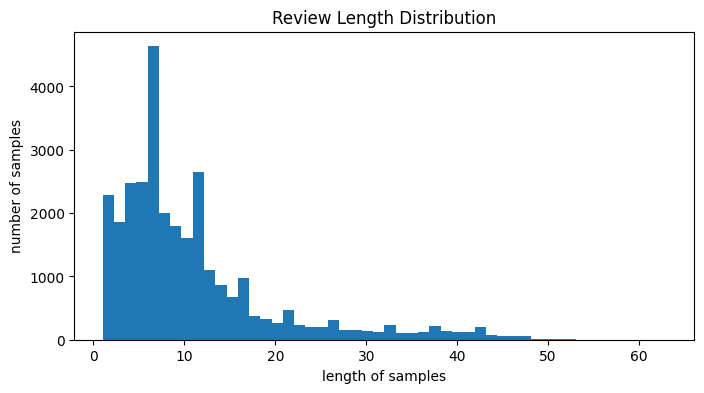

In [ ]:
# 리뷰 길이 분포 확인
review_lengths = [len(sentence) for sentence in tokenized_data]

print('리뷰의 최대 길이:', max(review_lengths))
print('리뷰의 평균 길이:', sum(review_lengths) / len(review_lengths))

plt.figure(figsize=(8, 4))
plt.hist(review_lengths, bins=50)
plt.xlabel('length of samples')
plt.ylabel('number of samples')
plt.title('Review Length Distribution')
plt.show()


## 7. Word2Vec 모델 학습

- `vector_size`: 임베딩 벡터 차원
- `window`: 주변 단어를 몇 칸까지 볼지 정하는 컨텍스트 윈도우 크기
- `min_count`: 이 횟수보다 적게 등장한 단어는 학습에서 제외
- `workers`: 학습에 사용할 CPU 프로세스 수
- `sg`: 0은 CBOW, 1은 Skip-gram


In [ ]:
# Word2Vec 모델 학습
# gensim 4.x부터는 size가 아니라 vector_size를 사용합니다.
model = Word2Vec(
    sentences=tokenized_data,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=0,
    seed=42,
    epochs=5
)

# 완성된 임베딩 행렬의 크기를 확인합니다.
# 출력 형태: (단어 수, 벡터 차원)
model.wv.vectors.shape


(5556, 100)

## 8. 유사 단어 출력

`most_similar()`는 입력 단어와 벡터 공간에서 가까운 단어를 찾아줍니다.

샘플 데이터만 학습한 경우 특정 단어가 어휘 사전에 없을 수 있으므로, 단어 존재 여부를 먼저 확인합니다.


In [ ]:
def show_similar_words(word: str, topn: int = 10):
    """Word2Vec 어휘 사전에 단어가 있으면 유사 단어를 출력합니다."""
    if word not in model.wv.key_to_index:
        print(f"'{word}'는 현재 모델의 어휘 사전에 없습니다.")
        print('USE_SAMPLE=False로 전체 데이터를 학습하거나, min_count를 낮춰보세요.')
        return []

    similar_words = model.wv.most_similar(word, topn=topn)
    for similar_word, score in similar_words:
        print(f'{similar_word}\t{score:.4f}')
    return similar_words


In [ ]:
# 예제: '최민식'과 유사한 단어 출력
show_similar_words('최민식')


신인	0.9886
시나리오	0.9884
조연	0.9874
대본	0.9851
역할	0.9844
비주	0.9839
각본	0.9835
개발	0.9832
최강	0.9824
내공	0.9823


[('신인', 0.9886347055435181),
 ('시나리오', 0.988376796245575),
 ('조연', 0.9873621463775635),
 ('대본', 0.985120415687561),
 ('역할', 0.9844055771827698),
 ('비주', 0.9839313626289368),
 ('각본', 0.9834796786308289),
 ('개발', 0.9831593036651611),
 ('최강', 0.9823958277702332),
 ('내공', 0.9822776317596436)]

In [ ]:
# 예제: '히어로'와 유사한 단어 출력
show_similar_words('히어로')


놀랍다	0.9929
전설	0.9925
무협	0.9920
웰	0.9918
슈퍼맨	0.9915
고전	0.9913
로맨스	0.9911
성룡	0.9909
액션영화	0.9908
로맨틱	0.9907


[('놀랍다', 0.9929399490356445),
 ('전설', 0.992466926574707),
 ('무협', 0.9919817447662354),
 ('웰', 0.9918450713157654),
 ('슈퍼맨', 0.991494357585907),
 ('고전', 0.9913339614868164),
 ('로맨스', 0.9910537600517273),
 ('성룡', 0.99085932970047),
 ('액션영화', 0.9908359050750732),
 ('로맨틱', 0.9906765222549438)]

In [ ]:
# 자주 등장할 가능성이 높은 단어로도 테스트해봅니다.
show_similar_words('영화')


명작	0.8053
다행	0.7947
수작	0.7827
지금껏	0.7799
애니	0.7727
드라마	0.7701
애니메이션	0.7697
작품	0.7665
국산	0.7663
졸작	0.7595


[('명작', 0.8052756786346436),
 ('다행', 0.794691264629364),
 ('수작', 0.7827146053314209),
 ('지금껏', 0.7798891663551331),
 ('애니', 0.772716760635376),
 ('드라마', 0.7701165676116943),
 ('애니메이션', 0.7697253823280334),
 ('작품', 0.7664754390716553),
 ('국산', 0.7663389444351196),
 ('졸작', 0.759476900100708)]

## 9. 모델 저장 및 불러오기

학습한 Word2Vec 모델은 파일로 저장해두면 이후 다시 토큰화와 학습을 하지 않고 바로 사용할 수 있습니다.


In [ ]:
# 모델 저장
model.save('nsmc_word2vec.model')

# 모델 불러오기
loaded_model = Word2Vec.load('nsmc_word2vec.model')

print('저장 및 불러오기 완료')
print('불러온 모델의 임베딩 행렬 크기:', loaded_model.wv.vectors.shape)


저장 및 불러오기 완료
불러온 모델의 임베딩 행렬 크기: (5556, 100)


## 10. 이름을 가진 개체 인식, Named Entity Recognition

NLTK를 사용해 영어 문장에서 사람, 조직, 지역 같은 개체명을 인식합니다.

예문: `James is working at Disney in London.`


In [ ]:
import nltk
from nltk import word_tokenize, pos_tag, ne_chunk

# NLTK 토큰화, 품사 태깅, 개체명 인식에 필요한 리소스를 다운로드합니다.
# NLTK 버전에 따라 필요한 리소스 이름이 조금 다를 수 있어 함께 다운로드합니다.
nltk_resources = [
    'punkt',
    'punkt_tab',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'maxent_ne_chunker',
    'maxent_ne_chunker_tab',
    'words',
]

for resource in nltk_resources:
    nltk.download(resource, quiet=True)


In [ ]:
# 토큰화와 품사 태깅을 동시에 수행합니다.
sentence = 'James is working at Disney in London.'
tagged_sentence = pos_tag(word_tokenize(sentence))

print(tagged_sentence)


[('James', 'NNP'), ('is', 'VBZ'), ('working', 'VBG'), ('at', 'IN'), ('Disney', 'NNP'), ('in', 'IN'), ('London', 'NNP'), ('.', '.')]


In [ ]:
# 품사 태깅 결과를 기반으로 개체명 인식을 수행합니다.
named_entity_tree = ne_chunk(tagged_sentence)

print(named_entity_tree)


(S
  (PERSON James/NNP)
  is/VBZ
  working/VBG
  at/IN
  (ORGANIZATION Disney/NNP)
  in/IN
  (GPE London/NNP)
  ./.)


In [ ]:
# 트리 구조에서 개체명만 보기 좋게 추출합니다.
named_entities = []

for subtree in named_entity_tree:
    if hasattr(subtree, 'label'):
        entity_name = ' '.join(word for word, tag in subtree.leaves())
        entity_label = subtree.label()
        named_entities.append((entity_name, entity_label))

named_entities


[('James', 'PERSON'), ('Disney', 'ORGANIZATION'), ('London', 'GPE')]